## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [3]:
from funcoes_monitoramento import *
from funcoes_psi import *

## Diretório

In [4]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Ordem

In [5]:
MODEL_ORDER = [
    # "BLEND_4",
    "BLEND3_3",
    "BLEND_REGRESSAO_2026",
    "BVS_CUSTOM",
    "HVA3",
    "HVA4",
]

MODEL_ORDER_GRAPH = [
    "BLEND_REGRESSAO_2026", 
    "BLEND3_3"]

MODEL_COL = "bureau_nm_ajust"
RATING_COL = "rating_score_ds"

MODEL_COLOR_MAP = {
    "BLEND_REGRESSAO_2026": "#3B82F6",
    "BLEND3_3": "#94A3B8",
    "BLEND_REGRESSAO_2026": "#8B5CF6",
    "BVS_CUSTOM": "#06B6D4",
    "HVA3": "#14B8A6",
    "HVA4": "#6366F1",
}

RATING_ORDER = ["A", "B", "C", "D", "E", "N/I"]
RATING_COLOR_MAP = {
    "A": "#7DD3FC",
    "B": "#5EEAD4",
    "C": "#93C5FD",
    "D": "#818CF8",
    "E": "#334155",
    "N/I": "#CBD5E1",
}
RATING_TEXT_COLOR_MAP = {
    "A": "white", "B": "white", "C": "black",
    "D": "white", "E": "white", "N/I": "black",
}

PRE_ANALISE_ORDER = ["APROVAR", "DERIVAR", "REPROVAR"]
PRE_ANALISE_COLOR_MAP = {
    "APROVAR": "#9ECACA",
    "DERIVAR": "#B5BFE8",
    "REPROVAR": "#9AA5B1",
}
PRE_ANALISE_TEXT_COLOR_MAP = {
    "APROVAR": "white", "DERIVAR": "white", "REPROVAR": "white",
}

FUNNEL_BINARY_STEPS = [
    "is_elegivel",
    "is_iniciada",
    "is_enviada",
    "is_aprovada",
    "is_ativada",
]

# FUNNEL_STEP_TITLES = {
#     "is_elegivel": "Elegível",
#     "is_iniciada": "Proposta iniciada",
#     "is_enviada": "Proposta enviada",
#     "is_aprovada": "Proposta aprovada",
#     "is_ativada": "Proposta ativada",
# }

BLEND_FUNNEL_METRICS = [
    "elegivel_pct_total",
    "iniciada_pct_elegivel",
    "enviada_pct_iniciada",
    "aprovada_pct_enviada",
    "ativada_pct_aprovada",
    "conversao_pct_total",
]

# BLEND_FUNNEL_LABELS = {
#     "elegivel_pct_total": "Elegível (% do total)",
#     "iniciada_pct_elegivel": "Iniciada (% dos elegíveis)",
#     "enviada_pct_iniciada": "Enviada (% das iniciadas)",
#     "aprovada_pct_enviada": "Aprovada (% das enviadas)",
#     "ativada_pct_aprovada": "Ativada (% das aprovadas)",
#     "conversao_pct_total": "Conversão (% do total)",
#     "enviada_pct_elegivel": "Enviada (% dos elegíveis)",
# }

# BLEND_FUNNEL_COLORS = {
#     "elegivel_pct_total": "#60A5FA",
#     "iniciada_pct_elegivel": "#38BDF8",
#     "enviada_pct_iniciada": "#F59E0B",
#     "aprovada_pct_enviada": "#FB923C",
#     "ativada_pct_aprovada": "#A78BFA",
#     "conversao_pct_total": "#34D399",
#     "enviada_pct_elegivel": "#FBBF24",
# }

In [6]:
WINDOW_DAYS = 8
WINDOW_WEEKS = 6

## Base: Blend4 em Produção

In [7]:
df_raw = pd.read_csv(ANALYTICS_DIR / "df_funil_blend3.csv", low_memory=False)
df_raw["requested_at"] = pd.to_datetime(df_raw["requested_at"])

for col in ["iniciada_at", "enviada_at", "activated_at", "cancelled_at"]:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col], errors="coerce")

# Flags padronizadas do funil blend
df = prepare_blend_funnel_columns(df_raw)
df = prepare_week_columns(df, "requested_at")
df = df[df[MODEL_COL] != "-1"].copy()

# Produção real: evita duplicar contrato entre BLEND_4 (simulado) e BLEND3_3 (prod)
df_prod = df[df[MODEL_COL] == df["bureau_nm"]].copy()

print(f"Volume total (simulação): {len(df):,}")
print(f"Contratos únicos: {df['contract_id'].nunique():,}")
print(f"Volume produção: {len(df_prod):,}")
print(f"Período: {df['requested_at'].min()} → {df['requested_at'].max()}")
df.head()

Volume total (simulação): 227,563
Contratos únicos: 227,563
Volume produção: 224,555
Período: 2026-05-01 00:00:00 → 2026-07-01 00:00:00


,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,tipo_contrato,product_nm,...,rating_cl_pol_blend4,rating_pol_blend4,is_elegivel,is_iniciada,is_enviada,is_aprovada,is_ativada,year,week_of_year,year_week
0,4321479,2026-07-01,2026-07-01,NaT,NaT,NaT,2026-07-01,NaN,PF,NaN,...,NaN,NaN,0,0,0,0,0,2026,27,2026-W27
1,4321887,2026-07-01,2026-07-01,NaT,NaT,NaT,NaT,NaN,PF,NaN,...,E-2.E,8.E,1,0,0,0,0,2026,27,2026-W27
2,4321991,2026-07-01,2026-07-01,2026-07-02,NaT,NaT,NaT,NaN,PF,Up,...,8.C,5.C,1,1,0,0,0,2026,27,2026-W27
3,4321358,2026-07-01,2026-07-01,2026-07-01,2026-07-01,2026-07-01,NaT,NaN,PF,Smart Plus,...,10.D,7.D,1,1,1,1,1,2026,27,2026-W27
4,4317204,2026-07-01,2026-07-01,NaT,NaT,NaT,2026-07-01,NaN,PF,NaN,...,E-2.E,8.E,0,0,0,0,0,2026,27,2026-W27


In [8]:
df.groupby("bureau_nm_ajust", dropna=False).size()

bureau_nm_ajust
BLEND3_3                194666
BLEND_REGRESSAO_2026     21675
BVS_CUSTOM                 806
HVA3                      9253
HVA4                      1133
NaN                         30
dtype: int64

In [9]:
df[df["bureau_nm_ajust"] == "HVA3"].groupby("qtd_proponentes", dropna=False).size()

qtd_proponentes
1.0     164
2.0    8371
3.0     621
4.0      90
5.0       4
6.0       2
7.0       1
dtype: int64

In [10]:
df[df["qtd_proponentes"] >= 2].groupby("bureau_nm_ajust", dropna=False).size()

bureau_nm_ajust
HVA3    9089
NaN       29
dtype: int64

NaN: Não temos BVS e nem SERASA. Parece ser falha. Multiproponente: Score do 1o e Renda Agregada. Dar uma olhada.

In [11]:
df_uniprop = df[df["qtd_proponentes"] == 1].copy()

df_multprop = df[df["qtd_proponentes"] >= 2].copy()

## Diário e Semanal

In [12]:
df_daily = filter_monitoring_window(
    df_uniprop,
    n_days=WINDOW_DAYS,
    mode="rolling",
)
df_daily_prod = filter_monitoring_window(
    df_prod,
    n_days=WINDOW_DAYS,
    mode="rolling",
)

print(f"Diário simulação: {df_daily['requested_at'].min()} → {df_daily['requested_at'].max()} | n={len(df_daily):,}")
print(f"Diário produção: {df_daily_prod['requested_at'].min()} → {df_daily_prod['requested_at'].max()} | n={len(df_daily_prod):,}")

Diário simulação: 2026-06-24 00:00:00 → 2026-07-01 00:00:00 | n=29,212
Diário produção: 2026-06-24 00:00:00 → 2026-07-01 00:00:00 | n=30,027


In [13]:
df_weekly = filter_monitoring_week_window(
    df_uniprop,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)
df_weekly_prod = filter_monitoring_week_window(
    df_prod,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)

print(f"Semanal simulação: {df_weekly['requested_at'].min()} → {df_weekly['requested_at'].max()} | n={len(df_weekly):,}")
print(f"Semanal produção: {df_weekly_prod['requested_at'].min()} → {df_weekly_prod['requested_at'].max()} | n={len(df_weekly_prod):,}")

Semanal simulação: 2026-05-25 00:00:00 → 2026-07-01 00:00:00 | n=140,794
Semanal produção: 2026-05-25 00:00:00 → 2026-07-01 00:00:00 | n=144,729


## Multiproponente vs. Uniproponente

In [14]:
PROPONENTE_ORDER = ["Uniproponente", "Multiproponente"]

PROPONENTE_COLOR_MAP = {
    "Uniproponente": "#94A3B8",   # slate
    "Multiproponente": "#3B82F6", # blue
}

PROPONENTE_TEXT_COLOR_MAP = {
    "Uniproponente": "white",
    "Multiproponente": "white",
}

def add_tipo_proponente(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["tipo_proponente"] = np.where(
        out["qtd_proponentes"] == 1,
        "Uniproponente",
        "Multiproponente",
    )
    return out

# Use df (BLEND4 + income > 0) ou df_raw (base completa)
df_prop = add_tipo_proponente(df)

print(df_prop["tipo_proponente"].value_counts(normalize=True).mul(100).round(2))
print(df_prop["tipo_proponente"].value_counts())

tipo_proponente
Uniproponente      95.99
Multiproponente     4.01
Name: proportion, dtype: float64
tipo_proponente
Uniproponente      218445
Multiproponente      9118
Name: count, dtype: int64


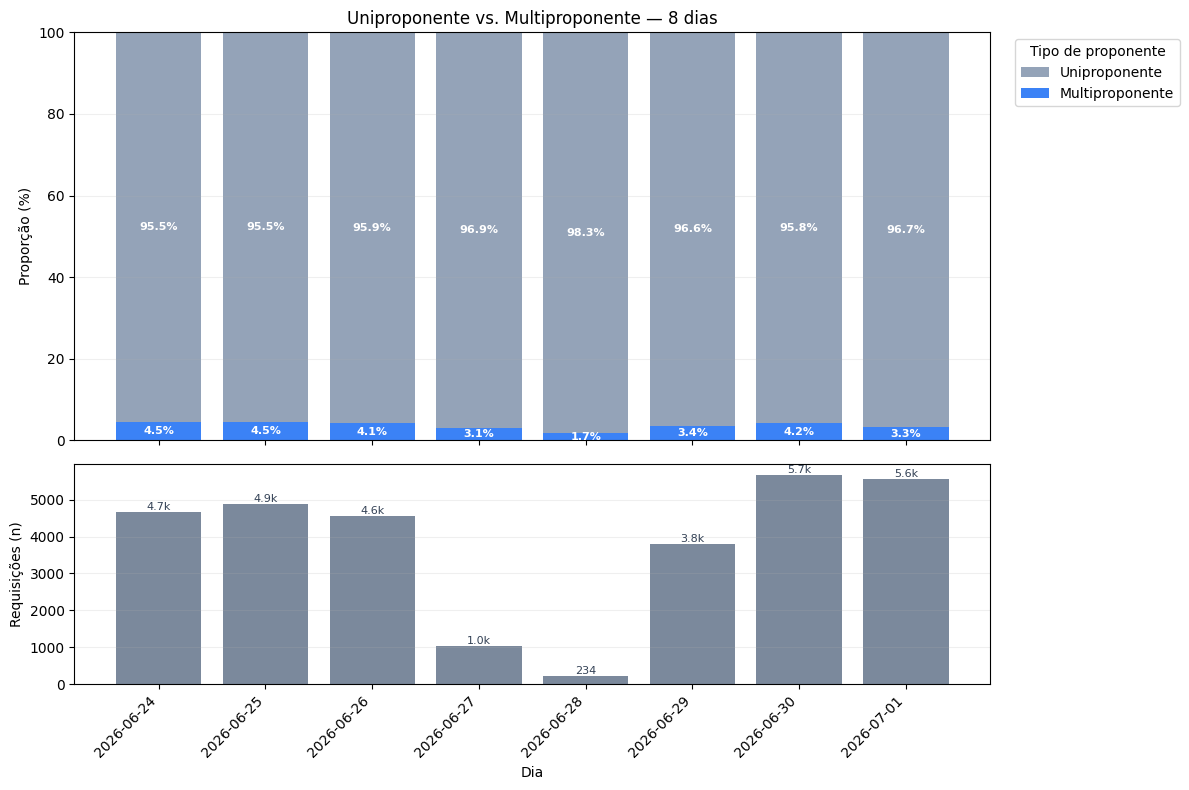

In [15]:
df_daily_prop = filter_monitoring_window(
    df_prop,
    n_days=WINDOW_DAYS,
    mode="rolling",
)

plot_daily_mix(
    df_daily_prop,
    category_col="tipo_proponente",
    title=f"Uniproponente vs. Multiproponente — {WINDOW_DAYS} dias",
    category_order=PROPONENTE_ORDER,
    color_map=PROPONENTE_COLOR_MAP,
    text_color_map=PROPONENTE_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Tipo de proponente",
    min_label_pct=1.0,
)

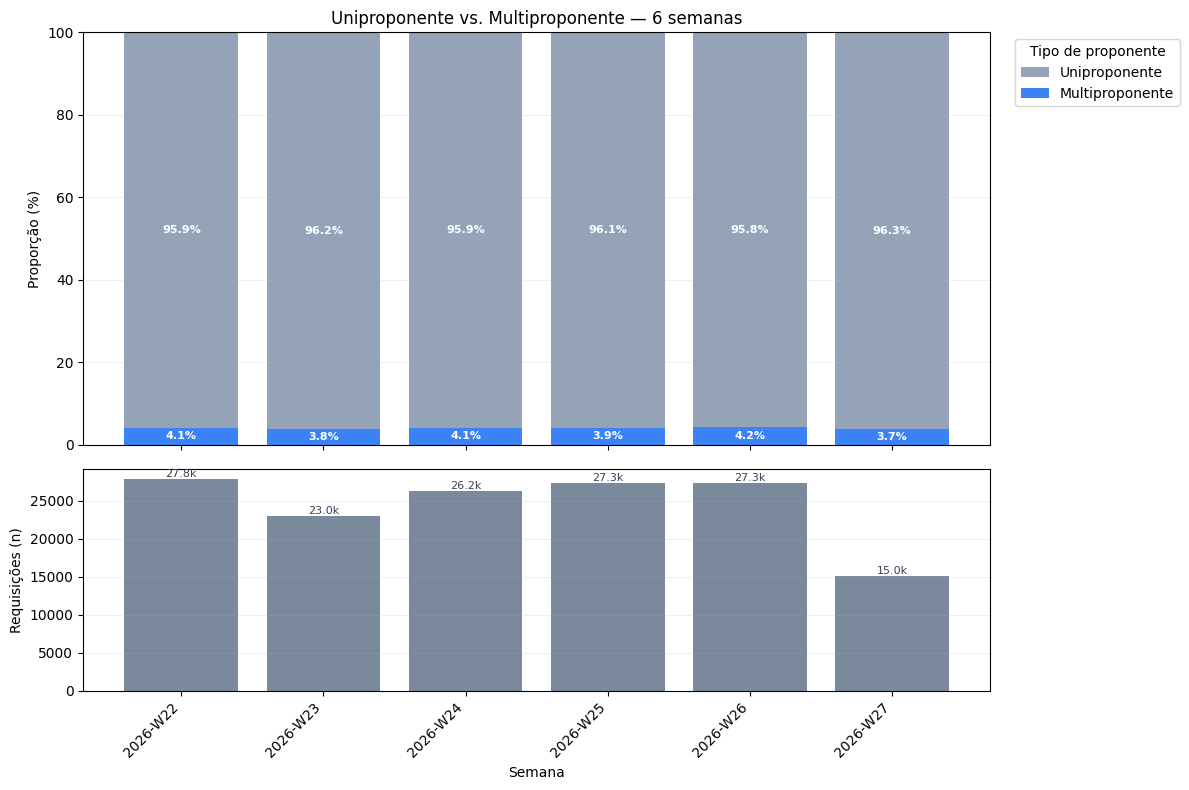

In [16]:
df_weekly_prop = filter_monitoring_week_window(
    df_prop,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)

plot_weekly_mix(
    df_weekly_prop,
    category_col="tipo_proponente",
    title=f"Uniproponente vs. Multiproponente — {WINDOW_WEEKS} semanas",
    category_order=PROPONENTE_ORDER,
    color_map=PROPONENTE_COLOR_MAP,
    text_color_map=PROPONENTE_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Tipo de proponente",
    min_label_pct=1.0,
)

## Mix de Modelos Diário e Semanal

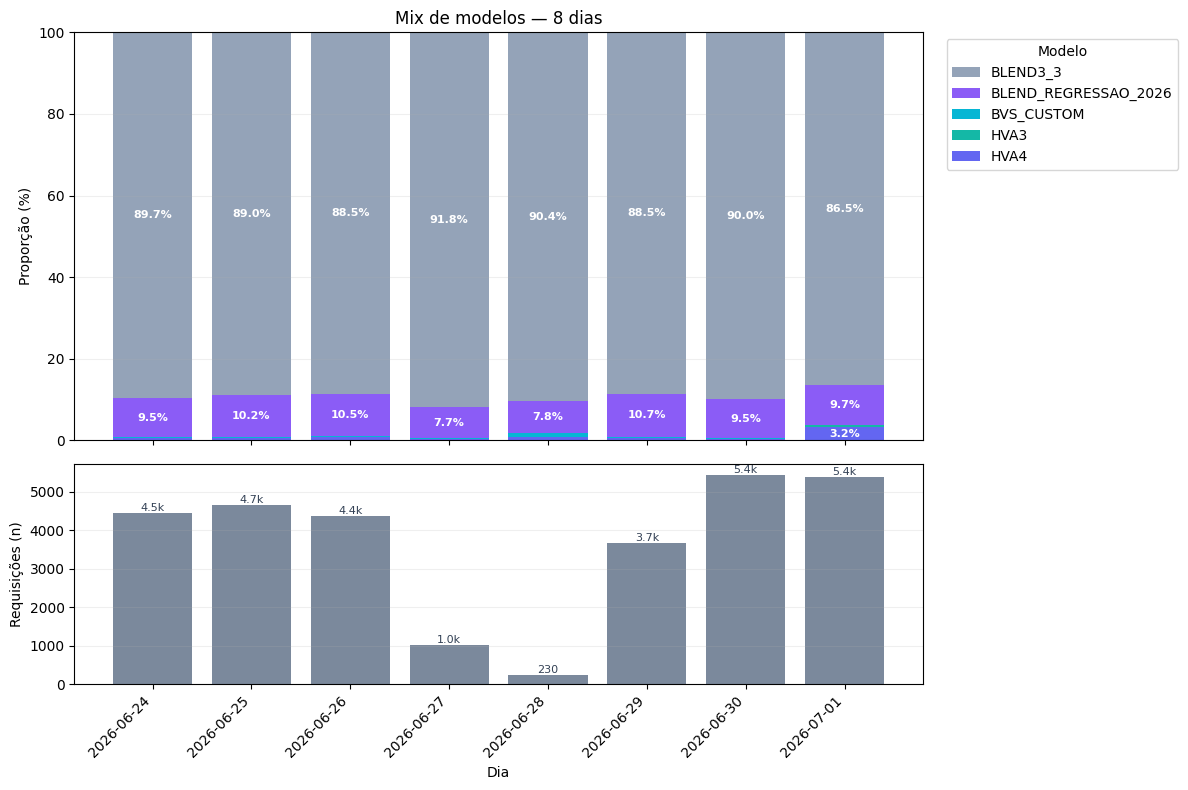

In [17]:
plot_daily_mix(
    df_daily,
    category_col=MODEL_COL,
    title=f"Mix de modelos — {WINDOW_DAYS} dias",
    category_order=MODEL_ORDER,
    color_map=MODEL_COLOR_MAP,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=3.0,
)

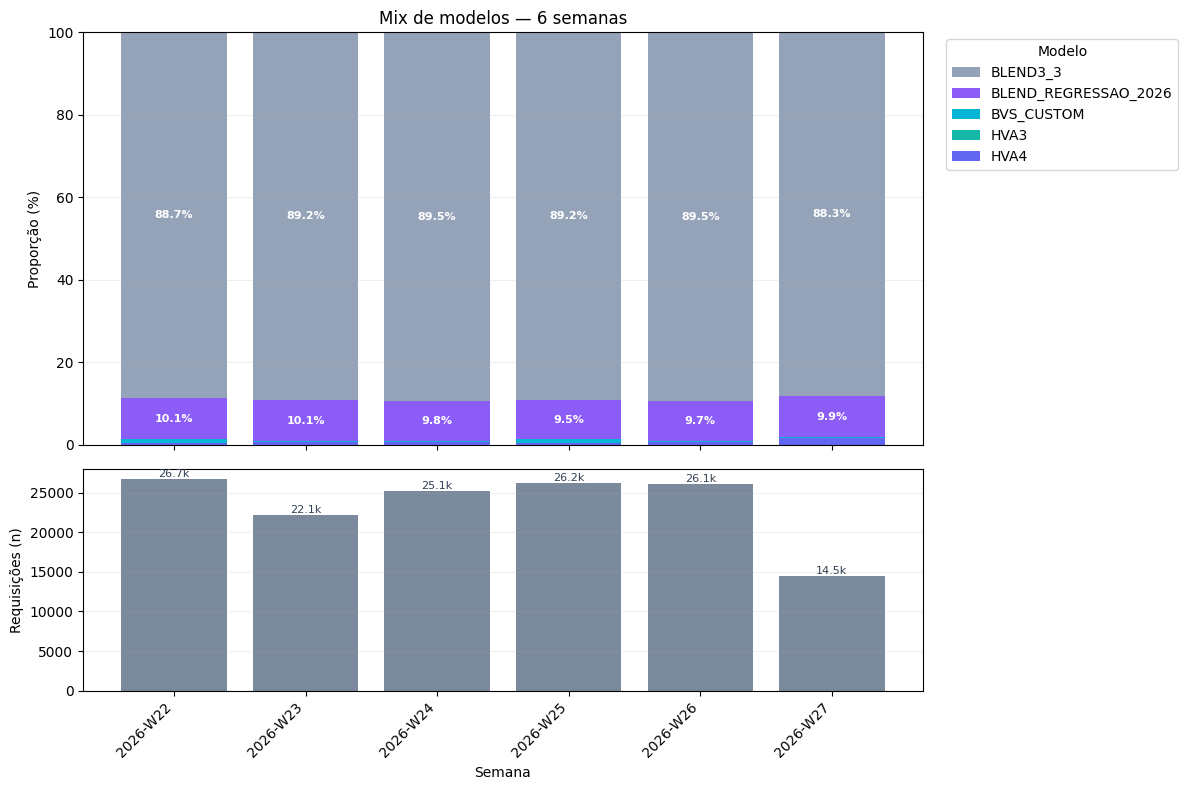

In [18]:
plot_weekly_mix(
    df_weekly,
    category_col=MODEL_COL,
    title=f"Mix de modelos — {WINDOW_WEEKS} semanas",
    category_order=MODEL_ORDER,
    color_map=MODEL_COLOR_MAP,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=3.0,
)

## Pré-Análise

Escala de DERIVAÇÃO

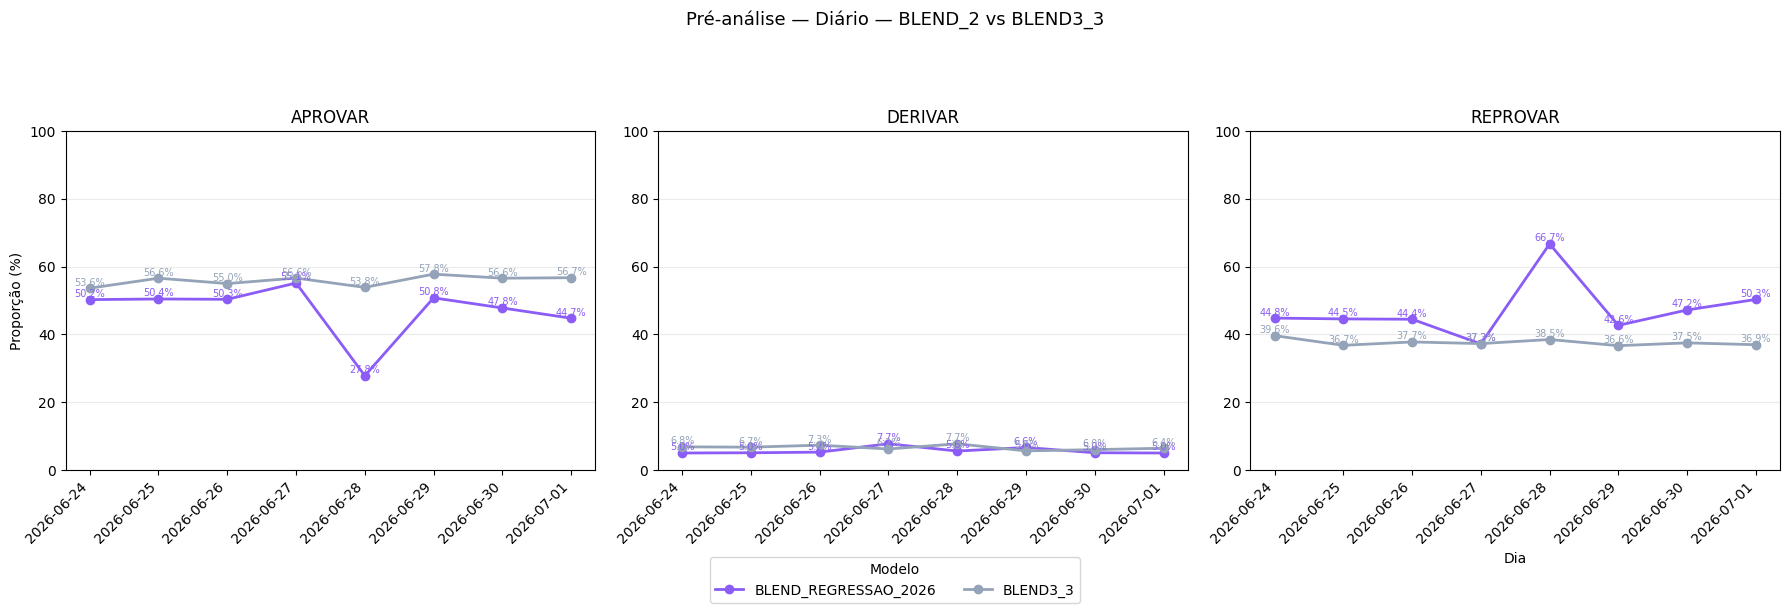

In [19]:
plot_pre_analysis_comparison(
    df_daily,
    models=MODEL_ORDER_GRAPH,
    time_grain="day",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Pré-análise — Diário — BLEND_2 vs BLEND3_3",
)

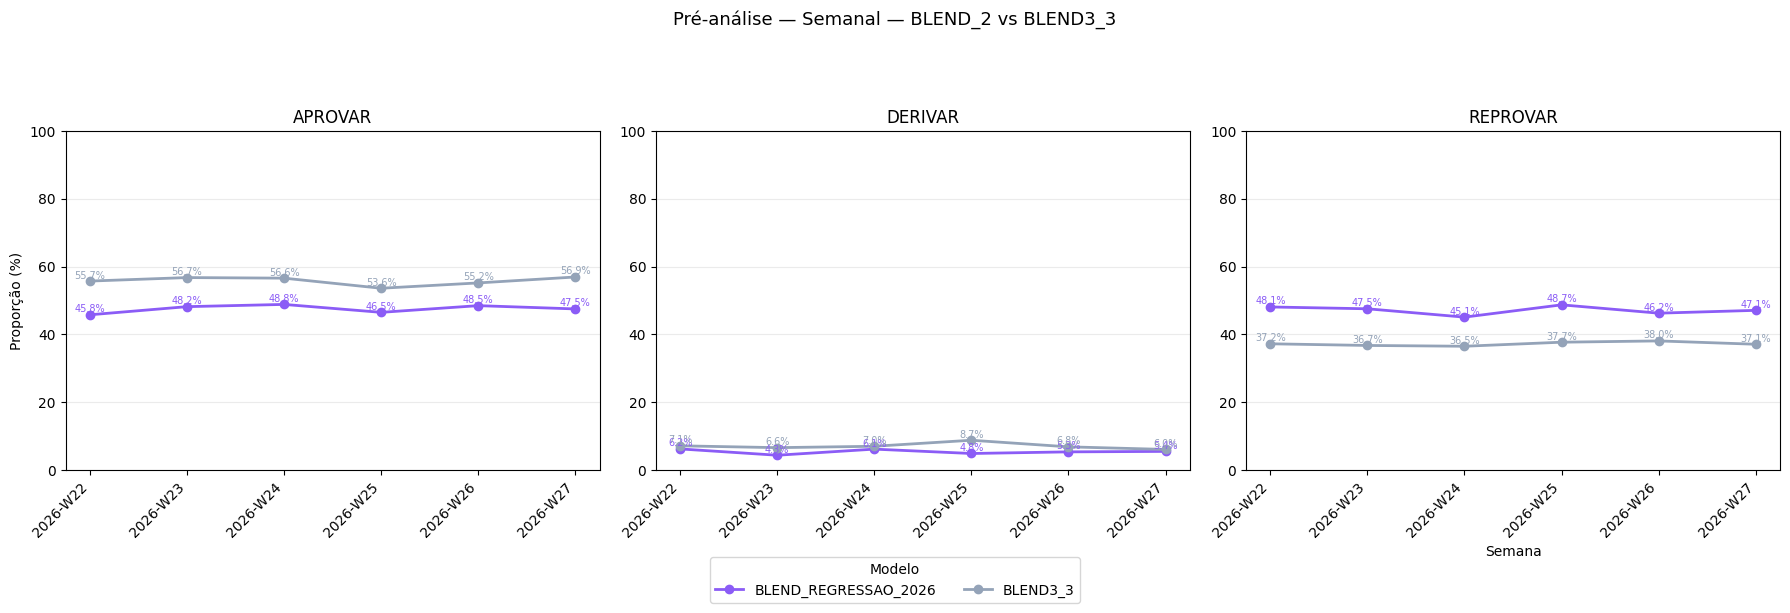

In [20]:
plot_pre_analysis_comparison(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    time_grain="week",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Pré-análise — Semanal — BLEND_2 vs BLEND3_3",
)

## Funil

Corrigir escala ATIVAÇÃO/CONVERSÃO

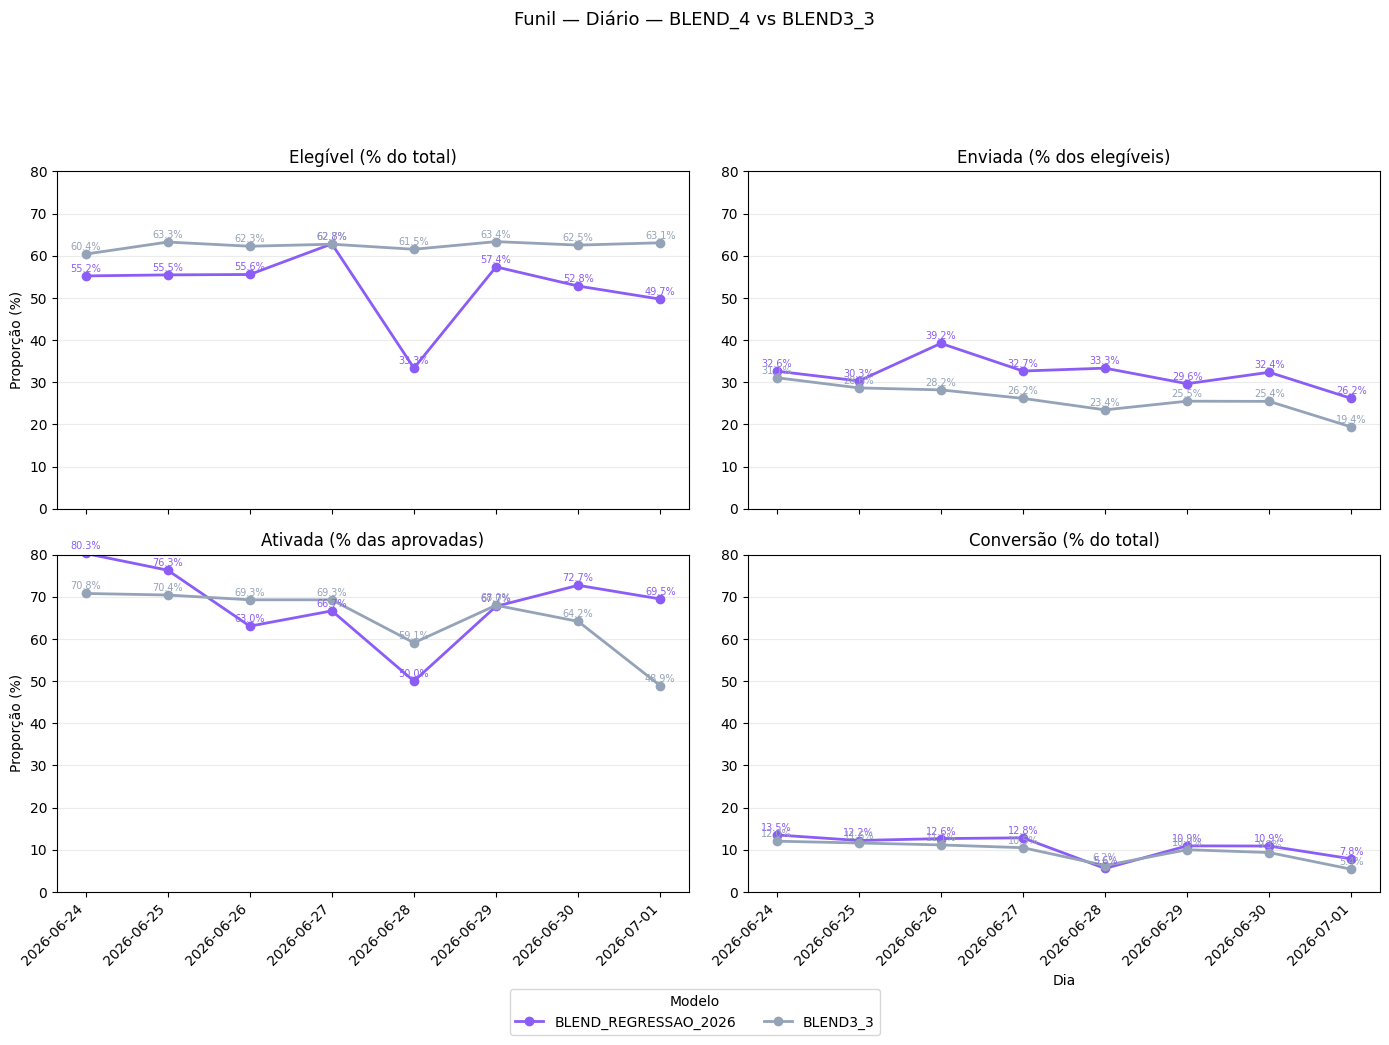

In [21]:
plot_funnel_metric_comparison(
    df_daily,
    models=MODEL_ORDER_GRAPH,
    metrics=FUNNEL_COMPARE_METRICS,
    time_grain="day",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Funil — Diário — BLEND_4 vs BLEND3_3",
)

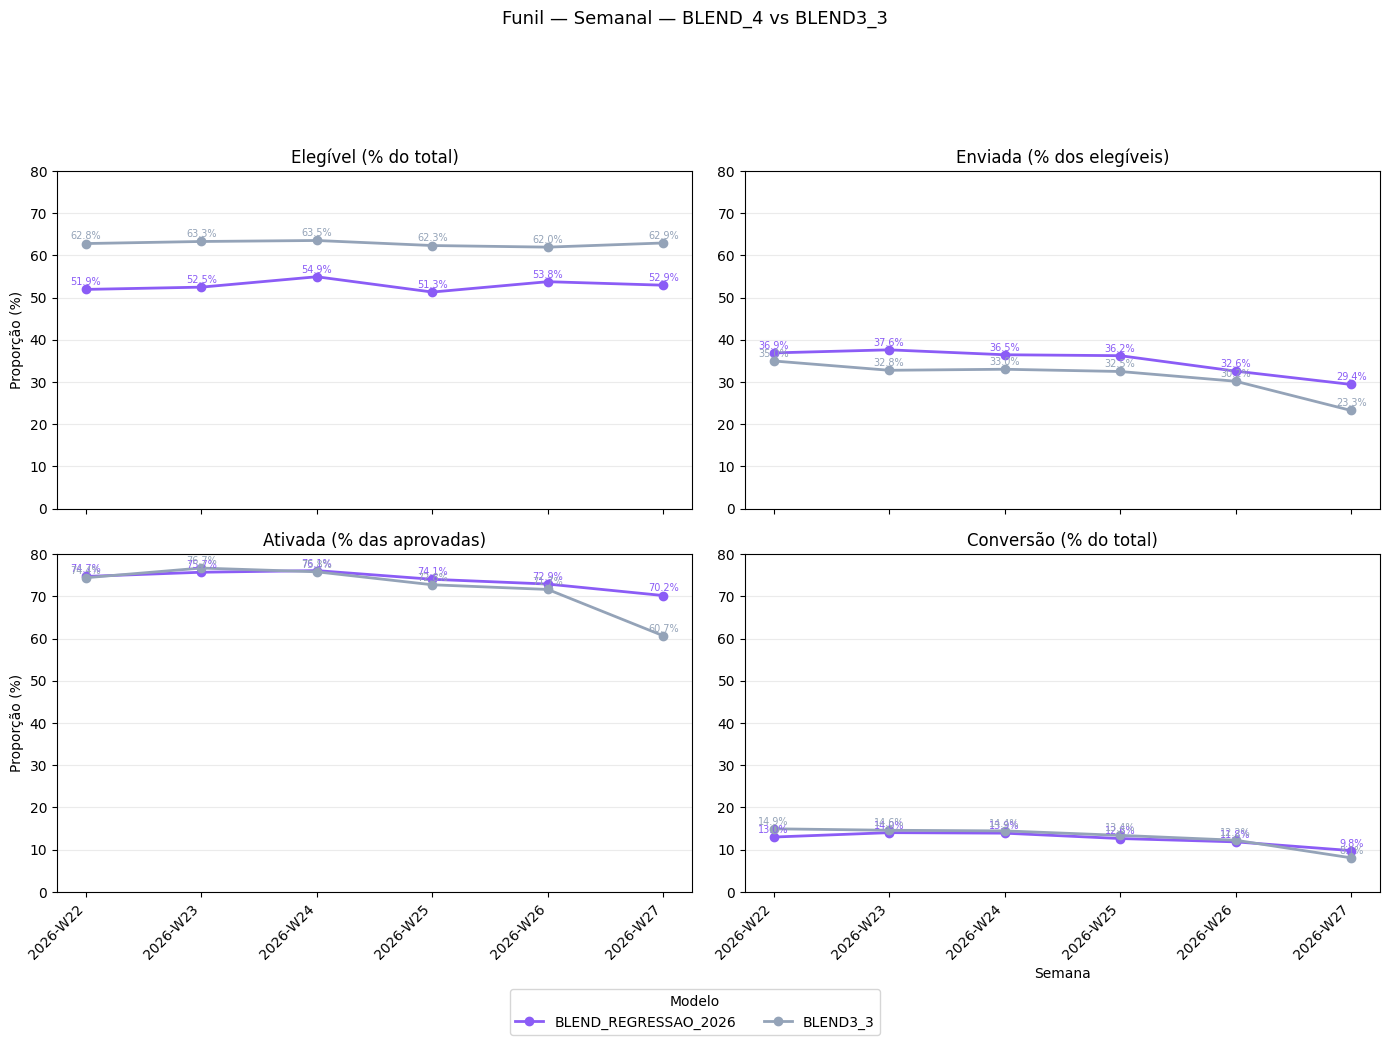

In [22]:
plot_funnel_metric_comparison(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    metrics=FUNNEL_COMPARE_METRICS,
    time_grain="week",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Funil — Semanal — BLEND_4 vs BLEND3_3",
)

## Tabela Resumo

ALTERAR LABEL DA SEMANA: 1o DIA DA SEMANA (2026-06-29)
WEEK: COMEÇAR A SEMANA NO DOMINGO E FINALIZAR NO SÁBADO

TROCAR COR HORROROSA

In [24]:
tabela_counts = build_blend_comparison_summary_table_counts(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    model_col=MODEL_COL,
    time_grain="week",
    baseline_model="BLEND_REGRESSAO_2026",
    challenger_model="BLEND3_3",
)

def color_negative_diff_counts(row):
    val = row.get(("diff_conversao", ""))
    if pd.notna(val) and val < 0:
        return ["background-color: #ffcccc"] * len(row)
    return [""] * len(row)

display(
    tabela_counts.style
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])
    .format("{:,.0f}")  # inteiros com separador de milhar
    .apply(color_negative_diff_counts, axis=1)
)

## Mix de Rating por Modelo

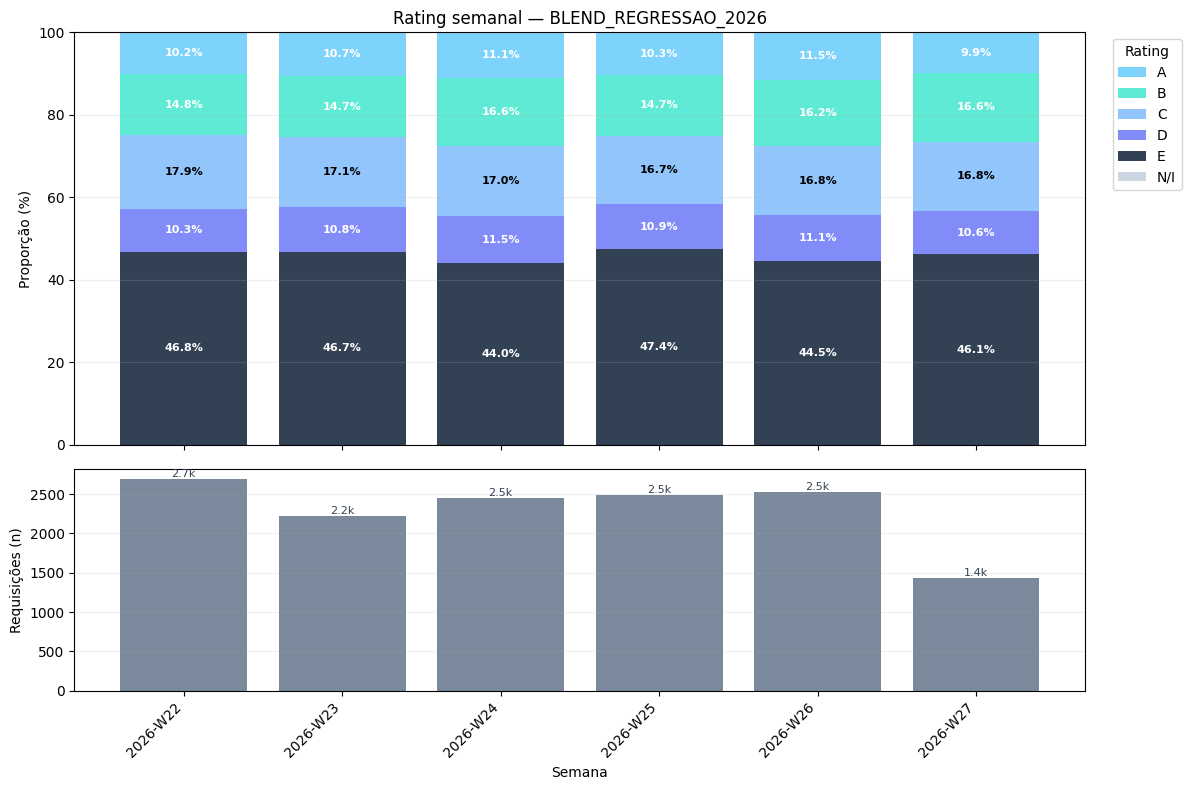

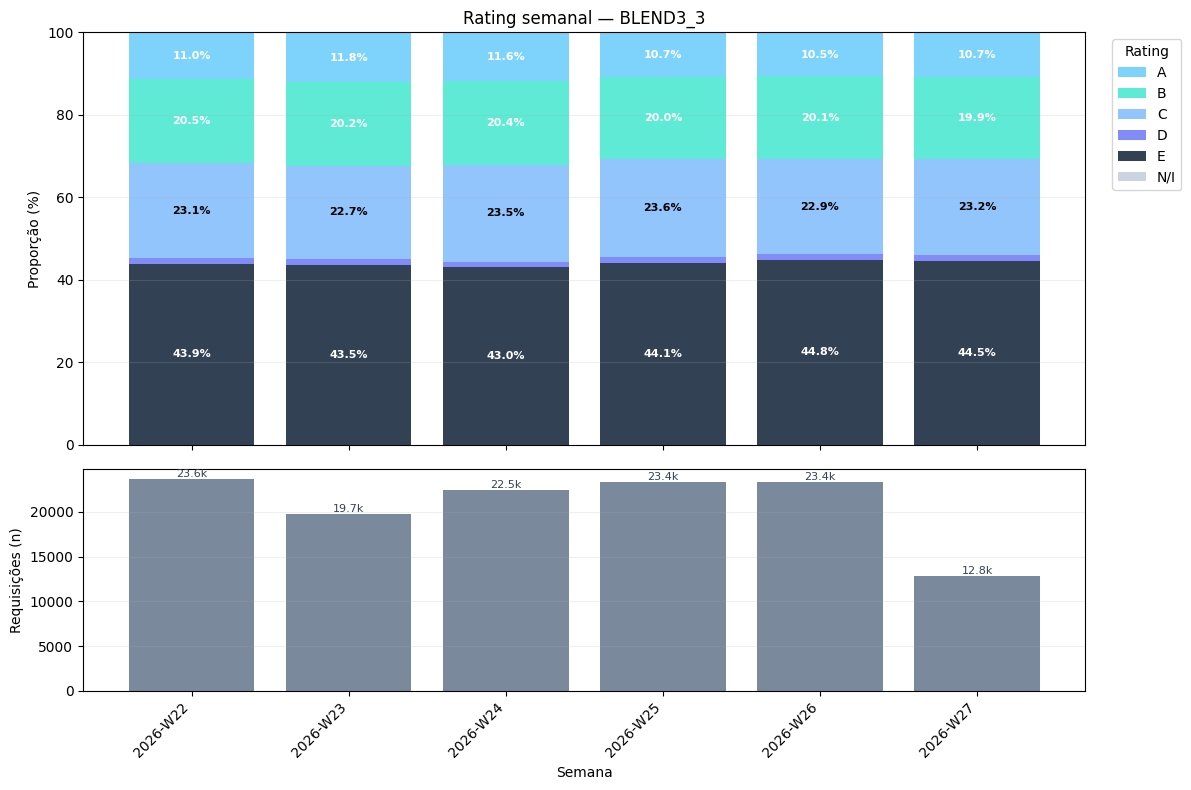

In [25]:
for model in MODEL_ORDER_GRAPH:
    df_model = df_weekly[df_weekly["bureau_nm_ajust"] == model]
    if df_model.empty:
        continue

    plot_weekly_mix(
        df_model,
        category_col="letra",
        title=f"Rating semanal — {model}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        legend_title="Rating",
        min_label_pct=5.0,
    )

## Funil por Rating

In [26]:
def build_funnel_by_rating_table(
    df,
    models,
    ratings=None,
    time_grain="week",
    model_col="bureau_nm_ajust",
    rating_col="rating_score_ds",
    min_volume_per_model=50,
):
    ratings = ratings or ["A", "B", "C", "D", "E"]
    metric_cols = ["elegivel_pct_total", "enviada_pct_elegivel", "conversao_pct_total"]
    rows = []

    for model in models:
        for rating in ratings:
            df_slice = df[(df[model_col] == model) & (df[rating_col] == rating)].copy()
            if df_slice.empty or len(df_slice) < min_volume_per_model:
                continue

            rates = compute_blend_funnel_rates(df_slice, time_grain=time_grain)
            if rates.empty:
                continue

            part = rates[["period", "volume"] + metric_cols].copy()
            part["model"] = model
            part["rating"] = rating
            rows.append(part)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    for col in metric_cols:
        out[col] = out[col].round(1)
    return out

In [27]:
MIN_VOLUME_WEEKLY = 100
RATINGS_TO_PLOT = ["A", "B", "C", "D", "E"]

MODEL_LABELS = {
    "BLEND_REGRESSAO_2026": "Blend 2",
    "BLEND3_3": "Blend 3",
}

METRICS = {
    "elegivel_pct_total": "Elegível (%)",
    "enviada_pct_elegivel": "Envio (%)",
    "conversao_pct_total": "Conversão (%)",
}

funnel_long = build_funnel_by_rating_table(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    min_volume_per_model=MIN_VOLUME_WEEKLY,
)

for metric_col, metric_label in METRICS.items():
    print(f"\n=== {metric_label} — Semanal — por rating ===")

    tabela = funnel_long.pivot_table(
        index="period",
        columns=["model", "rating"],
        values=metric_col,
        aggfunc="first",
    ).sort_index()

    # Renomeia colunas para ficar legível
    tabela.columns = pd.MultiIndex.from_tuples([
        (MODEL_LABELS.get(model, model), f"Rating {rating}")
        for model, rating in tabela.columns
    ])

    display(
        tabela.style
        .format("{:.1f}", na_rep="—")
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "center")]},
        ])
    )


=== Elegível (%) — Semanal — por rating ===



=== Envio (%) — Semanal — por rating ===



=== Conversão (%) — Semanal — por rating ===


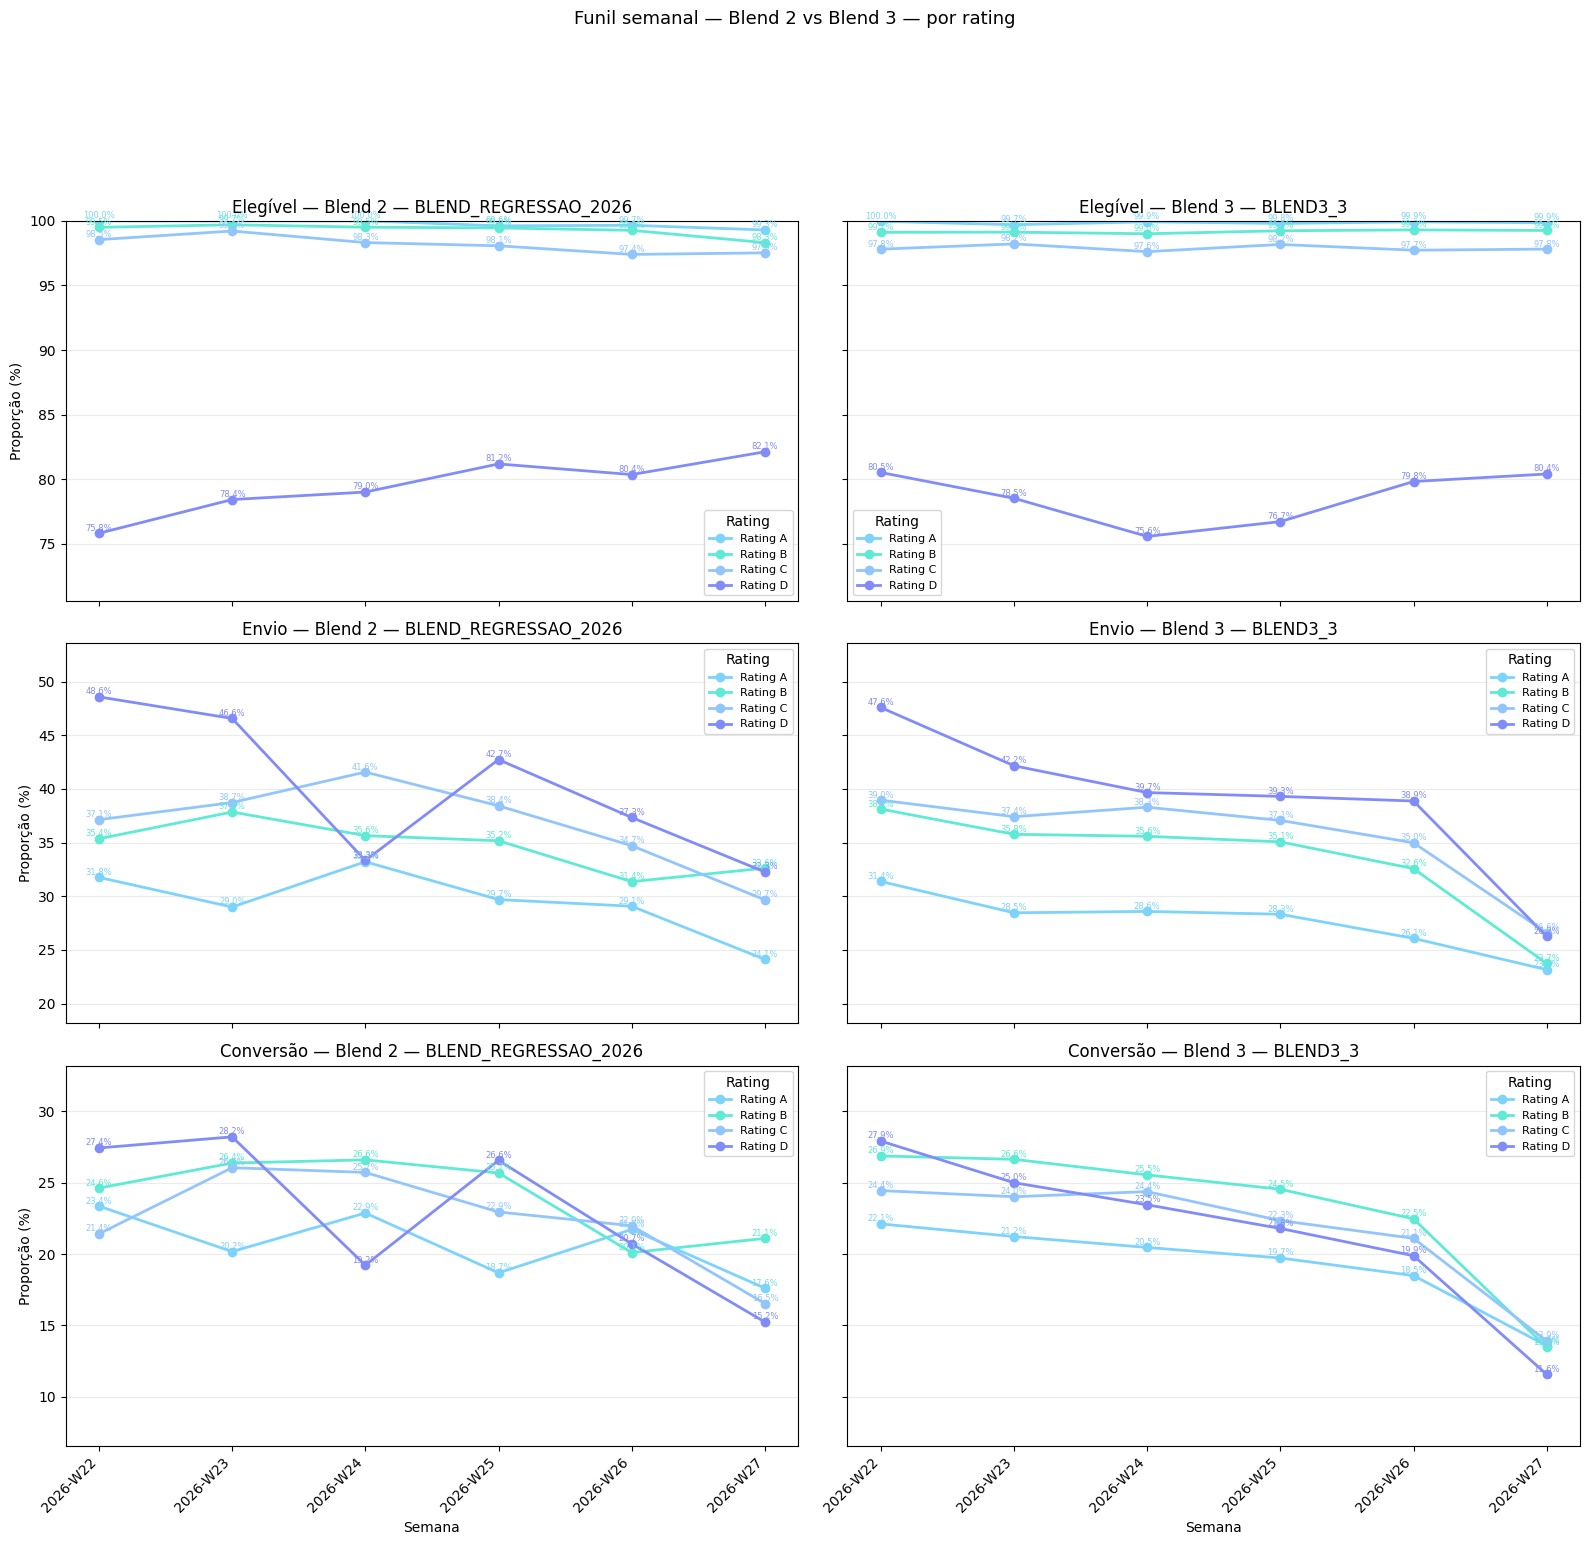

In [28]:

RATINGS_TO_PLOT = ["A", "B", "C", "D"]
plot_funnel_metrics_by_rating_side_by_side(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    min_volume_per_model=MIN_VOLUME_WEEKLY,
    ylim=None,              # auto por linha
    auto_ylim_pad=5.0,      # margem acima/abaixo dos dados
    show_labels=True,
    suptitle="Funil semanal — Blend 2 vs Blend 3 — por rating",
)

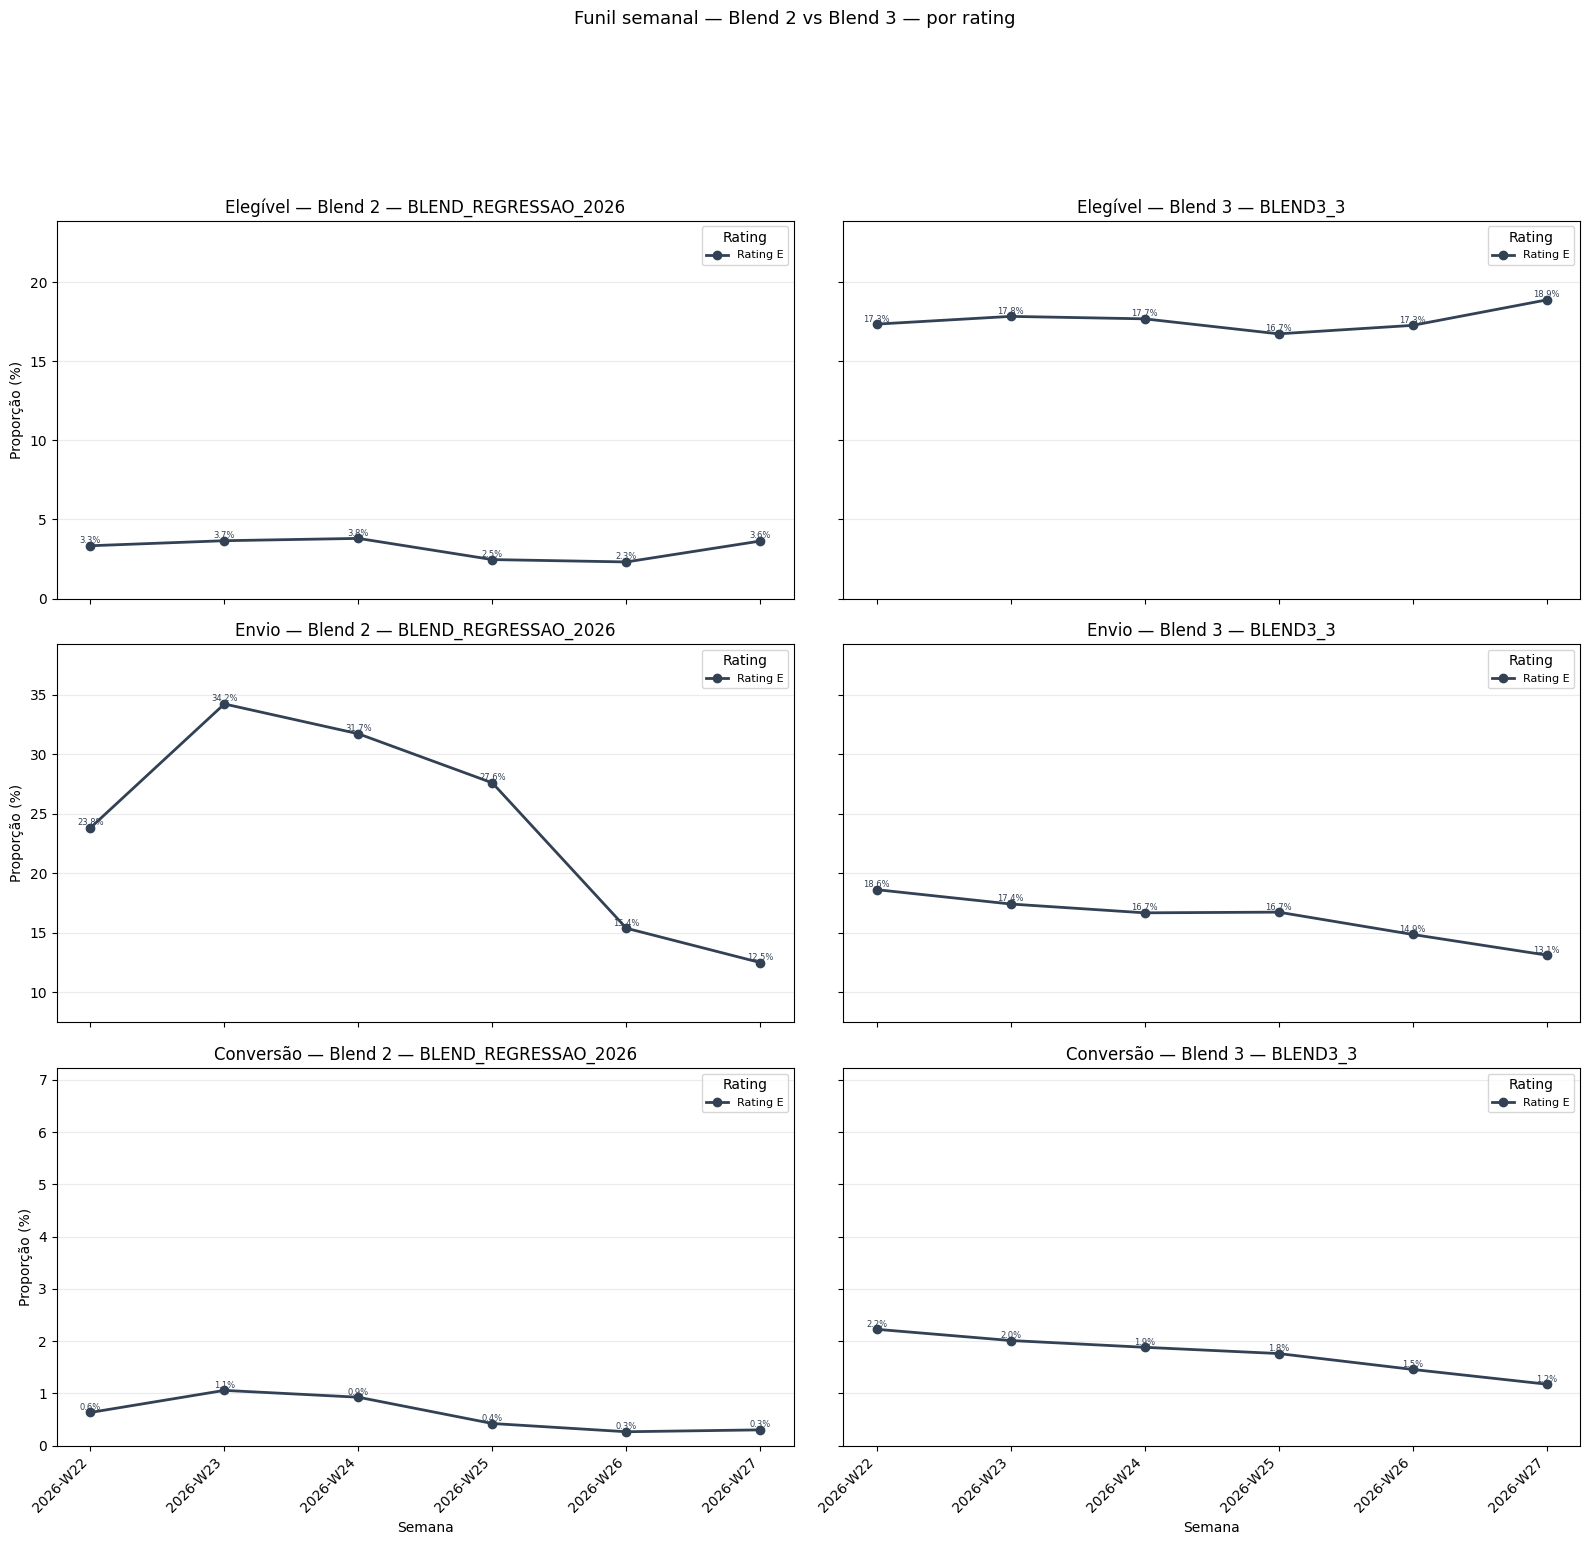

In [29]:

RATINGS_TO_PLOT = ["E"]
plot_funnel_metrics_by_rating_side_by_side(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    min_volume_per_model=MIN_VOLUME_WEEKLY,
    ylim=None,              # auto por linha
    auto_ylim_pad=5.0,      # margem acima/abaixo dos dados
    show_labels=True,
    suptitle="Funil semanal — Blend 2 vs Blend 3 — por rating",
)

## Pré-Análise por Rating

=== Pré-análise por rating — Semanal — BLEND_4 vs BLEND3_3 ===


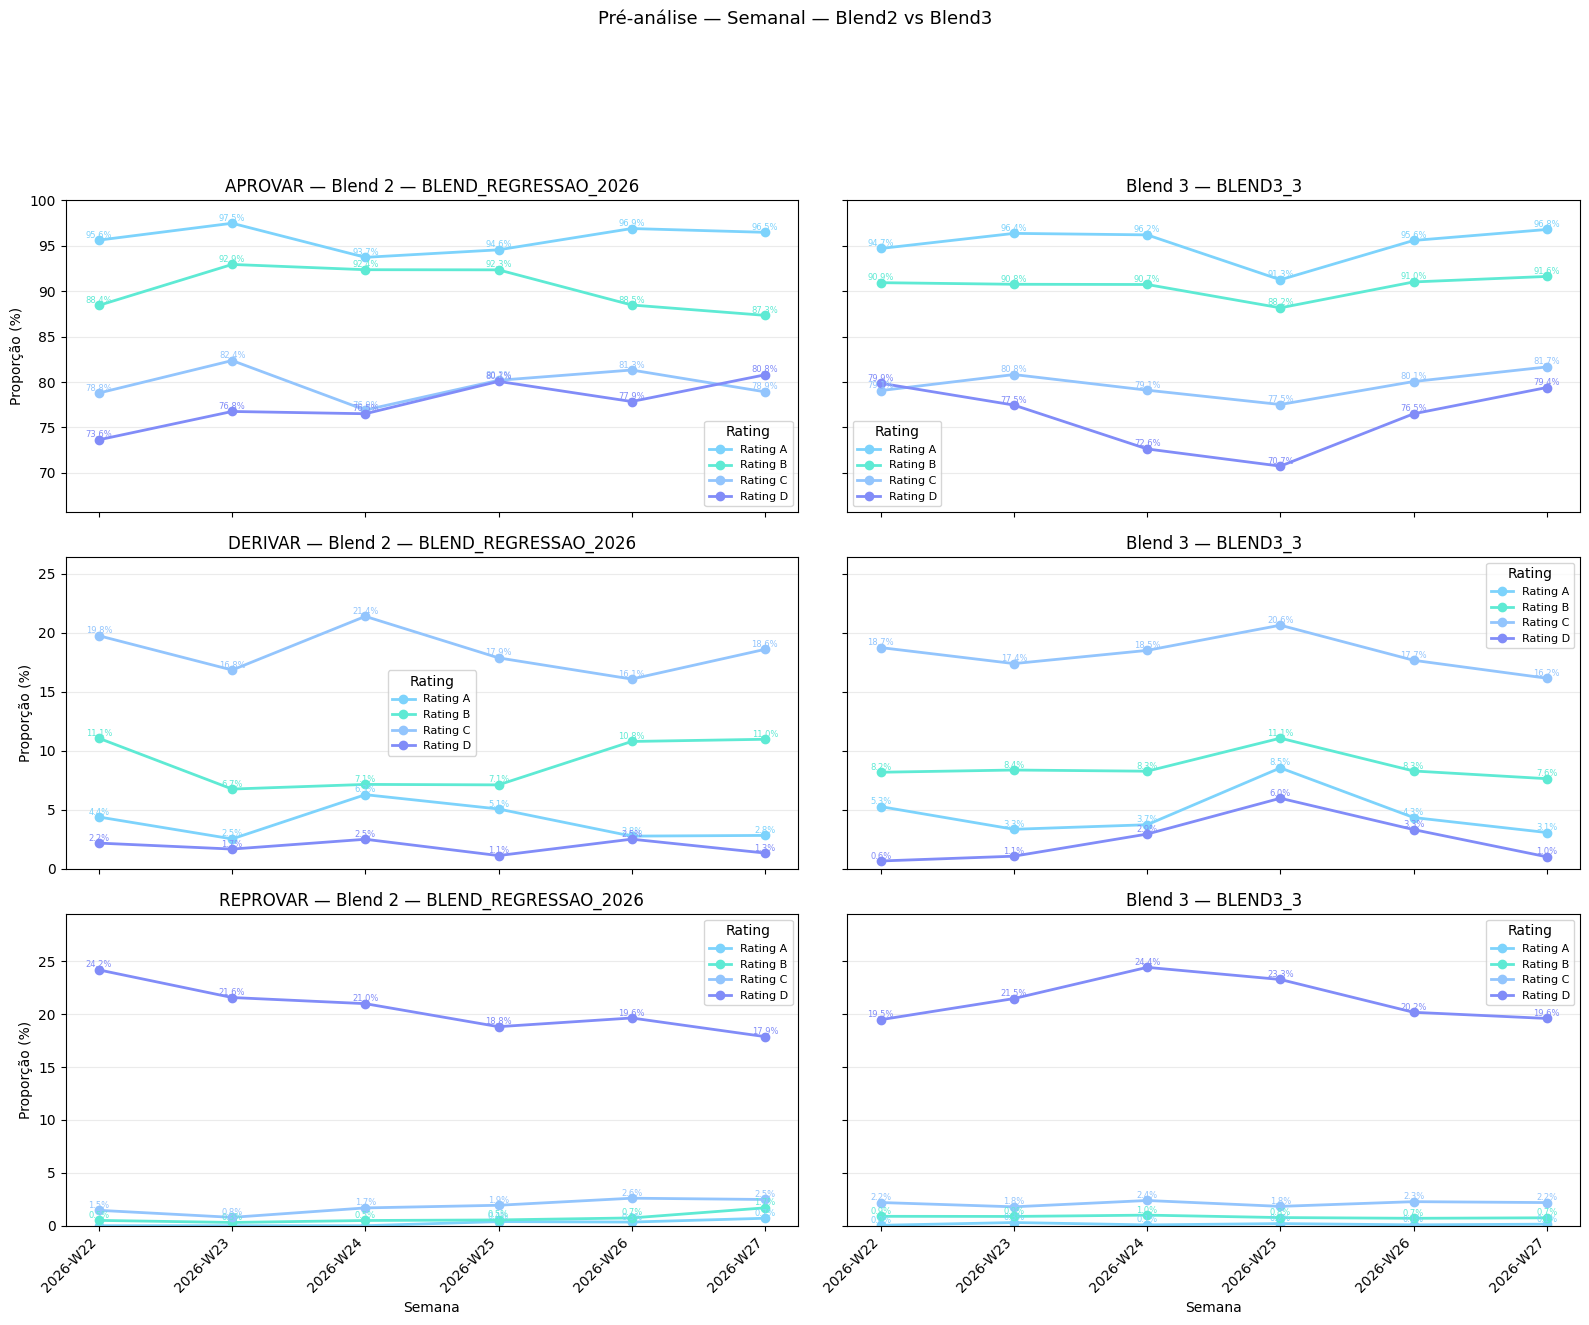

In [30]:
print("=== Pré-análise por rating — Semanal — BLEND_4 vs BLEND3_3 ===")

MIN_VOLUME_WEEKLY = 100
RATINGS_TO_PLOT = ["A", "B", "C", "D"]  # sem N/I, se preferir

plot_pre_analysis_by_rating_side_by_side(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    rating_color_map=RATING_COLOR_MAP,
    min_volume_per_model=MIN_VOLUME_WEEKLY,
    # ylim=None  ← padrão: auto por linha
    suptitle="Pré-análise — Semanal — Blend2 vs Blend3",
)

=== Pré-análise por rating — Semanal — BLEND_4 vs BLEND3_3 ===


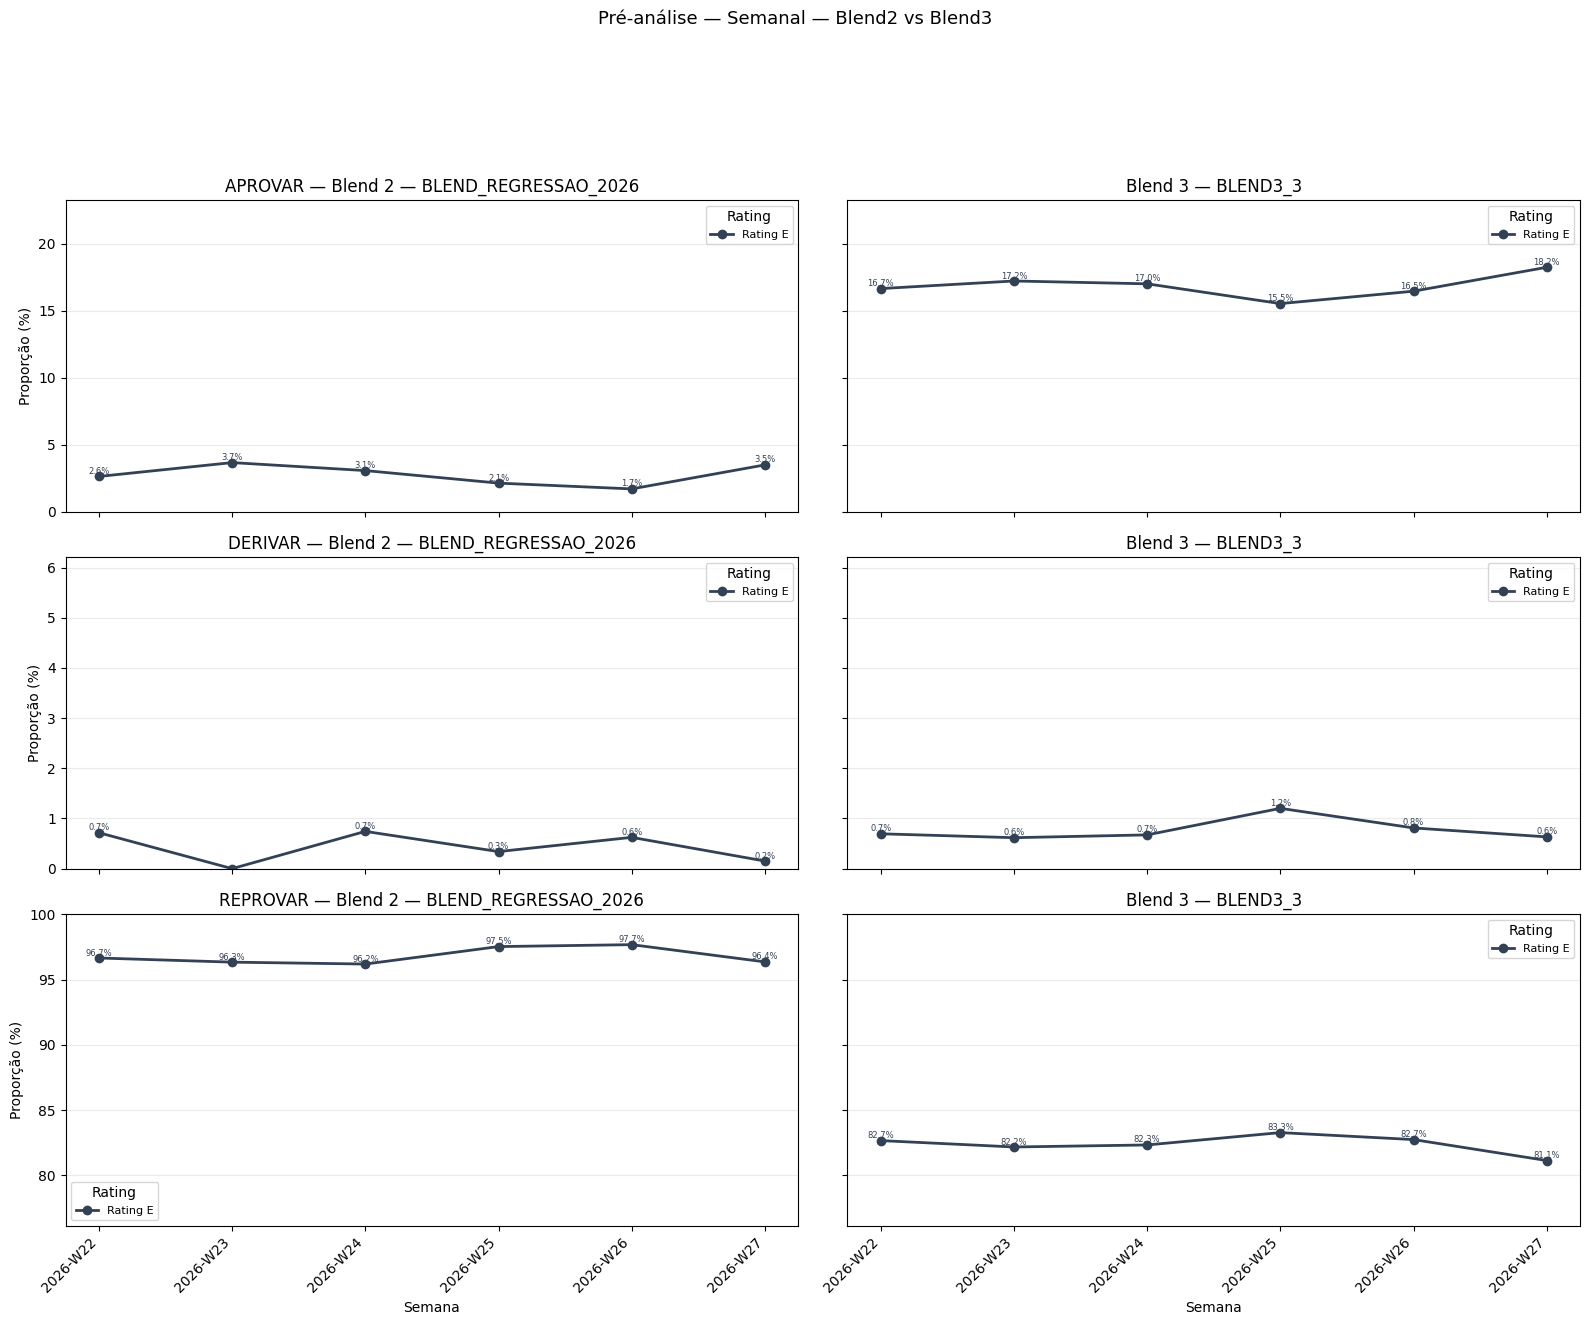

In [31]:
print("=== Pré-análise por rating — Semanal — BLEND_4 vs BLEND3_3 ===")

MIN_VOLUME_WEEKLY = 100
RATINGS_TO_PLOT = ["E"]  # sem N/I, se preferir

plot_pre_analysis_by_rating_side_by_side(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    rating_color_map=RATING_COLOR_MAP,
    min_volume_per_model=MIN_VOLUME_WEEKLY,
    # ylim=None  ← padrão: auto por linha
    suptitle="Pré-análise — Semanal — Blend2 vs Blend3",
)

## Funil Produção

=== Funil completo — Diário — Produção ===


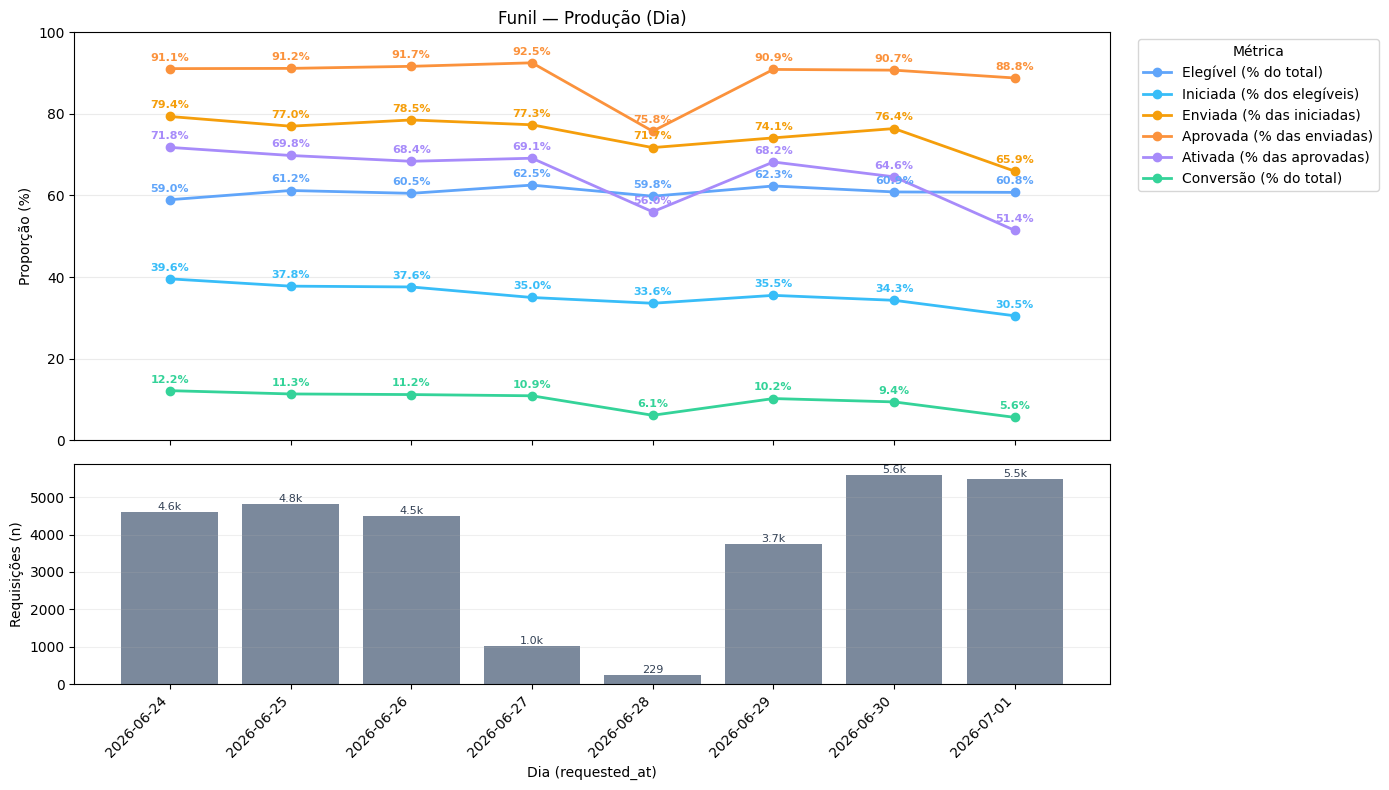

,period,volume,elegivel_pct_total,iniciada_pct_elegivel,enviada_pct_iniciada,enviada_pct_elegivel,aprovada_pct_enviada,ativada_pct_aprovada,conversao_pct_total
0,2026-06-24,4608,59.0,39.6,79.4,31.4,91.1,71.8,12.2
1,2026-06-25,4830,61.2,37.8,77.0,29.1,91.2,69.8,11.3
2,2026-06-26,4502,60.5,37.6,78.5,29.5,91.7,68.4,11.2
3,2026-06-27,1028,62.5,35.0,77.3,27.1,92.5,69.1,10.9
4,2026-06-28,229,59.8,33.6,71.7,24.1,75.8,56.0,6.1
5,2026-06-29,3749,62.3,35.5,74.1,26.4,90.9,68.2,10.2
6,2026-06-30,5599,60.9,34.3,76.4,26.3,90.7,64.6,9.4
7,2026-07-01,5482,60.8,30.5,65.9,20.1,88.8,51.4,5.6


In [33]:
print("=== Funil completo — Diário — Produção ===")
rates = compute_blend_funnel_rates(df_daily_prod, time_grain="day")
plot_blend_funnel_with_volume(
    rates,
    title="Funil — Produção (Dia)",
    xlabel="Dia (requested_at)",
    rate_columns=BLEND_FUNNEL_METRICS,
    ylim=(0, 100),
)
display(rates.round(1))

=== Funil completo — Diário — Produção ===


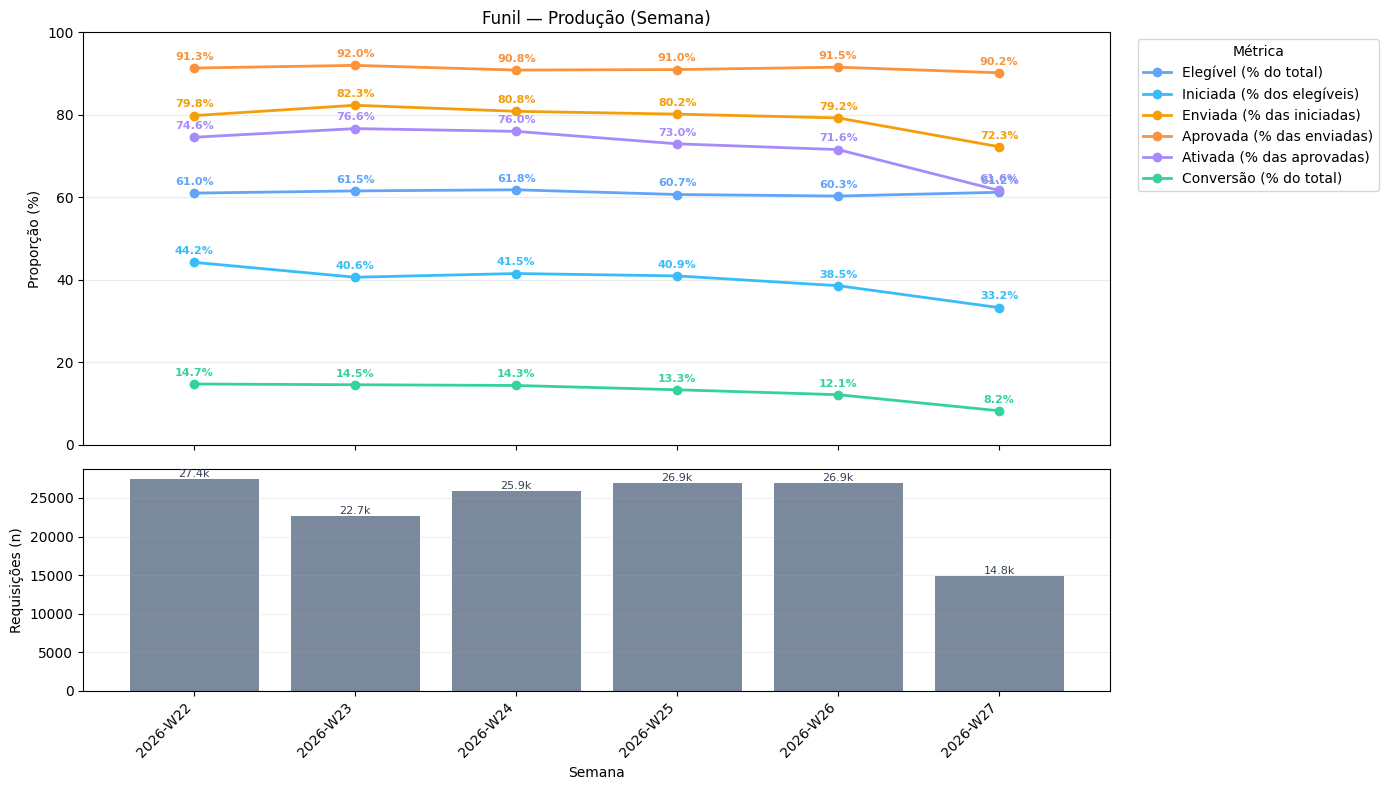

,period,volume,elegivel_pct_total,iniciada_pct_elegivel,enviada_pct_iniciada,enviada_pct_elegivel,aprovada_pct_enviada,ativada_pct_aprovada,conversao_pct_total
0,2026-W22,27424,61.0,44.2,79.8,35.3,91.3,74.6,14.7
1,2026-W23,22685,61.5,40.6,82.3,33.4,92.0,76.6,14.5
2,2026-W24,25901,61.8,41.5,80.8,33.6,90.8,76.0,14.3
3,2026-W25,26946,60.7,40.9,80.2,33.0,91.0,73.0,13.3
4,2026-W26,26943,60.3,38.5,79.2,30.6,91.5,71.6,12.1
5,2026-W27,14830,61.2,33.2,72.3,24.0,90.2,61.6,8.2


In [34]:
print("=== Funil completo — Diário — Produção ===")
rates = compute_blend_funnel_rates(df_weekly_prod, time_grain="week")
plot_blend_funnel_with_volume(
    rates,
    title="Funil — Produção (Semana)",
    xlabel="Semana",
    rate_columns=BLEND_FUNNEL_METRICS,
    ylim=(0, 100),
)
display(rates.round(1))